#Atividade 01

Aluna: Maria Eduarda Alves (meas2@cesar.school)

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
!pip install "numpy<2" yfinance pydataset pmdarima

In [3]:
# importando bibliotecas
from pmdarima.arima import KPSSTest
import pandas as pd
import os
import numpy as np
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

Dados referentes ao google trends da amazon ao longo de 2005 até 2019.

Google Trends -> se refere ao número de buscas da palavra Amazon na internet

---



## Exploração dos dados

In [4]:
df = pd.read_csv('/content/amazon_trends.csv')

In [5]:
df.head()

,Date,Google_Trends
0,2005-01-01,37
1,2005-01-02,68
2,2005-01-03,56
3,2005-01-04,82
4,2005-01-05,42


In [6]:
df['Date'].unique()

array(['2005-01-01', '2005-01-02', '2005-01-03', ..., '2019-11-16',
       '2019-11-17', '2019-11-18'], dtype=object)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5435 entries, 0 to 5434
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Date           5435 non-null   object
 1   Google_Trends  5435 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 85.1+ KB


In [8]:
df.describe()

,Google_Trends
count,5435.000000
mean,58.641582
std,15.002440
min,0.000000
25%,47.000000
50%,57.000000
75%,70.000000
max,100.000000


## Aula 1

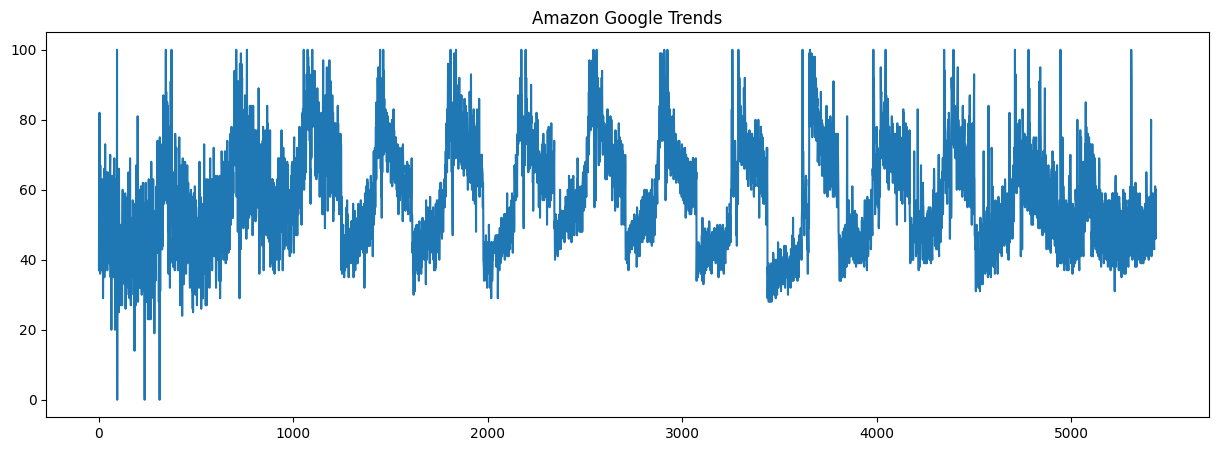

In [9]:
plt.figure(figsize=(15,5))
df['Google_Trends'].plot()
plt.title('Amazon Google Trends')
plt.show()

Observações:

* A série aparentemente indica picos de sazonalidade.


### Visualização de tendência

In [10]:
def create_trend(df: pd.DataFrame, trend_size: int | float):
  return df.rolling(trend_size).mean().values

In [11]:
df['trend_30d'] = create_trend(df['Google_Trends'], 30)
df['trend_120d'] = create_trend(df['Google_Trends'], 120)

<Figure size 1500x500 with 0 Axes>

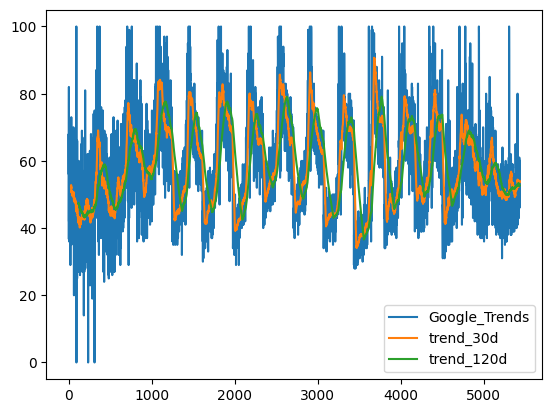

In [12]:
plt.figure(figsize=(15,5))
df[["Google_Trends","trend_30d","trend_120d"]].plot()
plt.show()

Observações:

* A trend de 120 dias é um pouco mais suavizada do que a de 30 dias.

### Autocorrelação

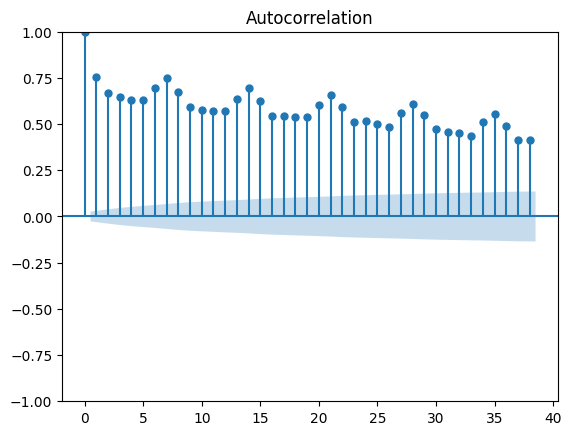

In [13]:
plot_acf(df['Google_Trends'])
plt.show()

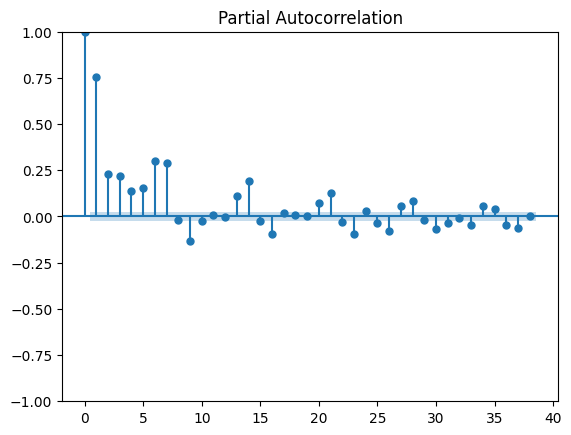

In [14]:
plot_pacf(df['Google_Trends'])
plt.show()

Observações:

* Na acf apresenta um declínio com picos positivos.
* Na pacf ela apresenta um declínio com picos menores e que começam a decair e ficar dentro do intervalo de confiança ou muito próximo dele.
* Tanto os gráficos de acf e pacf apresentam picos regulares que podem indicar sazonalidade dos dados.

## Aula 2

### Diferenciação

In [15]:
def differentiate(data: pd.DataFrame | pd.Series, m: int = 1):
  diffs = []
  for t in range(m, len(data)):
    diffs.append(data.values[t] - data.values[t - m])

  return pd.DataFrame({f"Diff(m={m})": diffs})

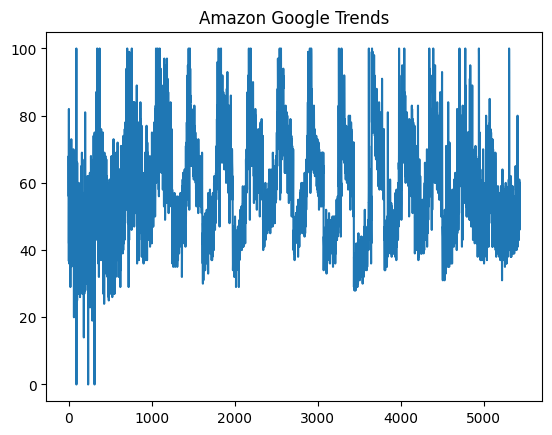

In [17]:
amazon_google_trends = df["Google_Trends"]
amazon_google_trends.plot()
plt.title("Amazon Google Trends")
plt.show()

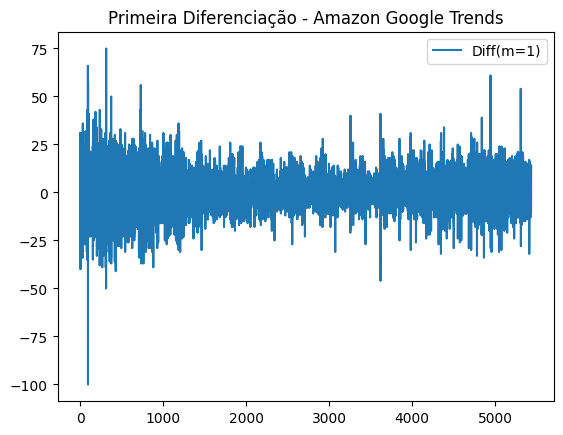

In [18]:
# Primeira diferenciação
amazon_google_trends_diff = differentiate(amazon_google_trends)
amazon_google_trends_diff.plot()
plt.title("Primeira Diferenciação - Amazon Google Trends")
plt.show()

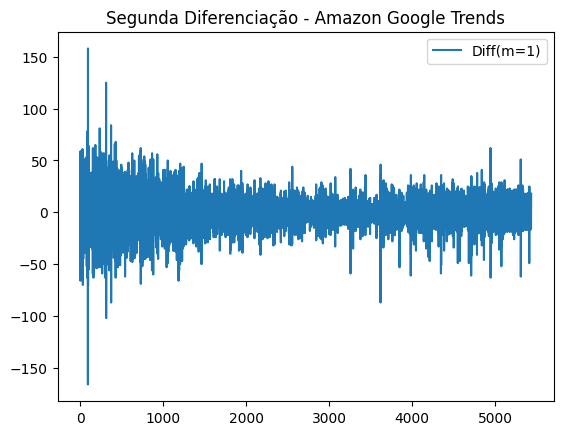

In [19]:
#Segunda diferenciação
amazon_google_trends_diff2 = differentiate(amazon_google_trends_diff["Diff(m=1)"])
amazon_google_trends_diff2.plot()
plt.title("Segunda Diferenciação - Amazon Google Trends")
plt.show()

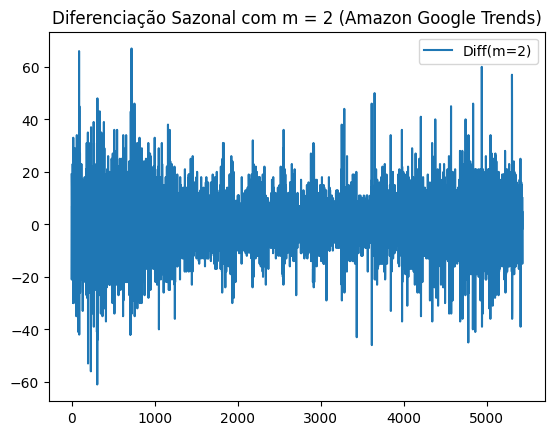

In [21]:
# Diferenciação sazonal
amazon_google_trends_diff_m2 = differentiate(amazon_google_trends, m=2)
amazon_google_trends_diff_m2.plot()
plt.title("Diferenciação Sazonal com m = 2 (Amazon Google Trends)")
plt.show()

Fazendo o KPSS teste para identificar se a série é ou não estacionária

In [22]:
kpss_ = KPSSTest()
kpss_df_amazon = kpss(df["Google_Trends"])
print(f"Kpps_Teste: {kpss_df_amazon}")

Kpps_Teste: (0.2048204308304231, 0.1, 42, {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739})


/tmp/ipython-input-2152264139.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_df_amazon = kpss(df["Google_Trends"])


In [23]:
print(f"KPSS Test [e estacionaria?]: {kpss_df_amazon[1] >= 0.05}")
print(kpss_.should_diff(df["Google_Trends"]))

KPSS Test [e estacionaria?]: True
(0.01418409944324847, True)


Segundo o KPSS teste a série não é **estacionária**. Neste caso, seria indicado realizar a diferenciação para seguir com os modelos.

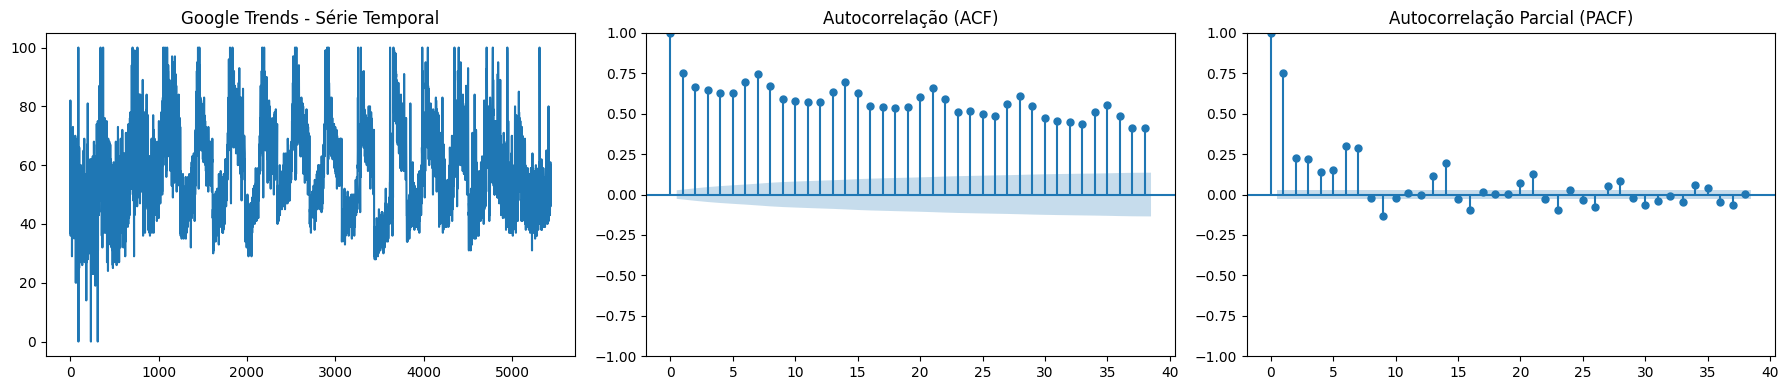

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Série temporal
df["Google_Trends"].plot(ax=axes[0])
axes[0].set_title("Google Trends - Série Temporal")

# ACF
plot_acf(df["Google_Trends"], ax=axes[1])
axes[1].set_title("Autocorrelação (ACF)")

# PACF
plot_pacf(df["Google_Trends"], ax=axes[2])
axes[2].set_title("Autocorrelação Parcial (PACF)")

plt.tight_layout()
plt.show()

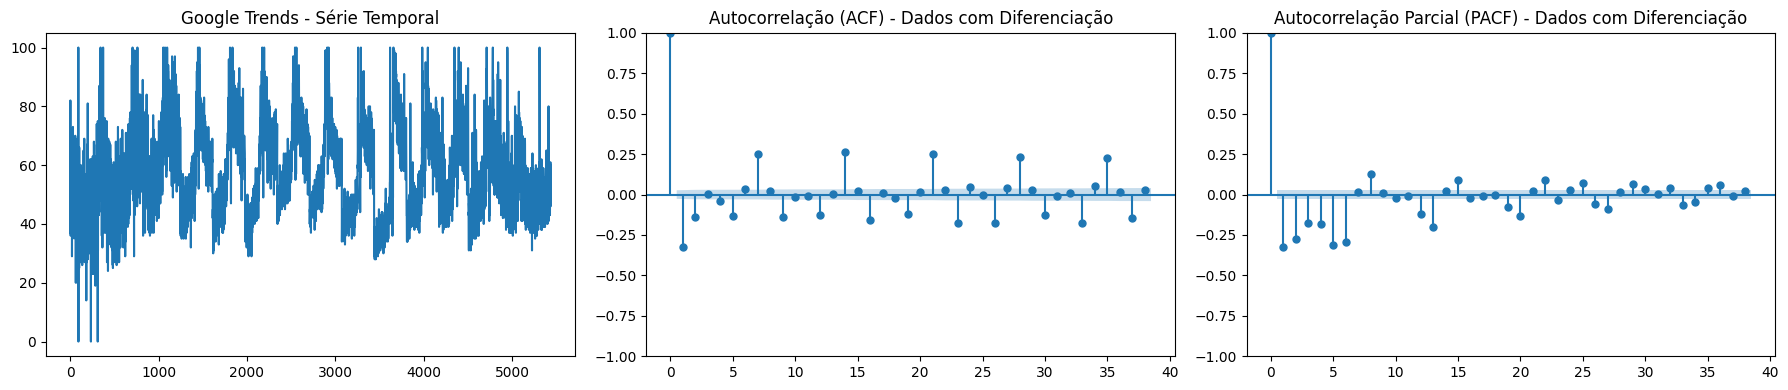

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Série temporal
df["Google_Trends"].plot(ax=axes[0])
axes[0].set_title("Google Trends - Série Temporal")

# ACF
plot_acf(amazon_google_trends_diff, ax=axes[1])
axes[1].set_title("Autocorrelação (ACF) - Dados com Diferenciação")

# PACF
plot_pacf(amazon_google_trends_diff, ax=axes[2])
axes[2].set_title("Autocorrelação Parcial (PACF) - Dados com Diferenciação")

plt.tight_layout()
plt.show()

### Modelos (AR, AM, ARMA, ARIMA, SARIMA)

---

AR - autoregressivo -> assume que valores futuros dependem de valores passados

MA - média móvel -> observações são uma combinação linear dos erros de termos do passado

ARMA - AR + MA -> combina o conceito de AR e MA para capturar padrões de curto e longo prazo

ARIMA -> expande o ARMA incluindo a diferenciação para lidar com dados não estacionários

**modelos sem diferenciação**

In [27]:
# ts - time series
ts = df['Google_Trends'].values
#ts_diff = differentiate(df['Google_Trends']).values

# tamanho do teste
test_size = int(len(ts) * 0.2) # 20% para teste

# df de treino e teste
X_train, X_test = ts[:-test_size], ts[-test_size: ]

In [28]:
lag = 12
d = 1

ma_model = ARIMA(X_train, order=[0, 0, lag]) # modelo de média movel - composto pelo ARIMA quando o p e d são zero
ar_model = ARIMA(X_train, order=[lag, 0, 0]) # modelo autoregressivo - composto pelo ARIMA quando o d e q são zero
arma_model = ARIMA(X_train, order=[lag, 0, lag]) # modelo ARMA ( autoregressivo + média móvel ) - composto pelo ARIMA quando a variável d = 0
arima_model = ARIMA(X_train, order=[lag, d, lag])

In [29]:
ma_results = ma_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

In [30]:
ar_results = ar_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

In [31]:
arma_results = arma_model.fit().predict(start=len(X_train),
                                        end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [32]:
arima_results = arima_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


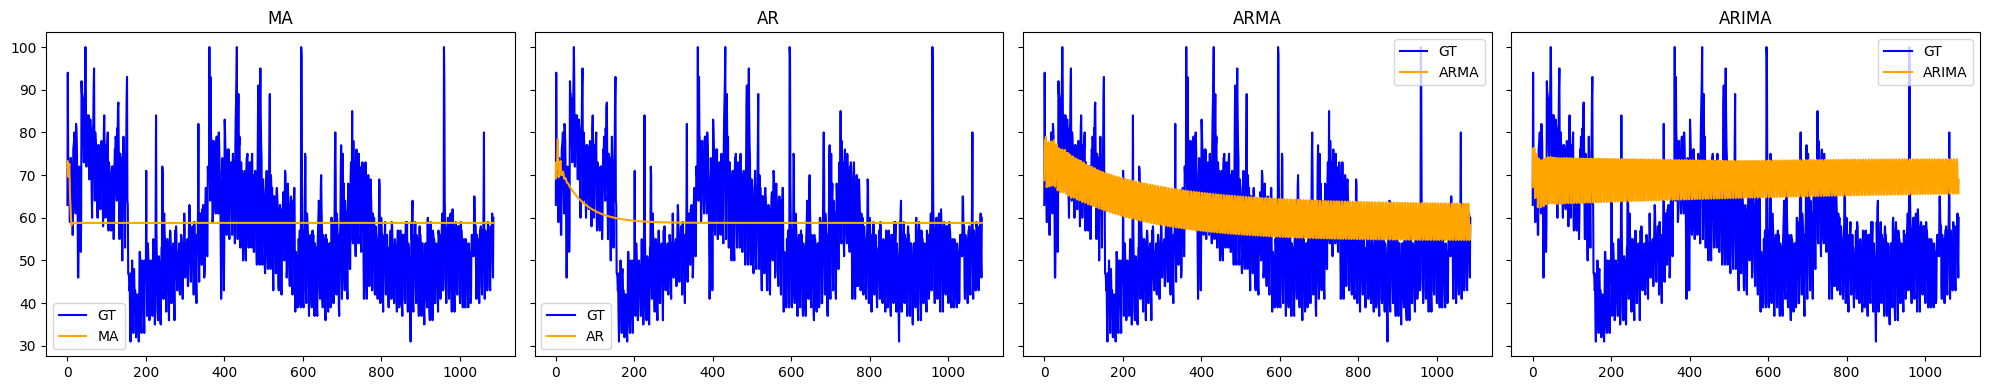

In [35]:
# resultados dos modelos
results = {
    "GT": X_test.squeeze(),
    "MA": ma_results,
    "AR": ar_results,
    "ARMA": arma_results,
    "ARIMA": arima_results
}

df_results = pd.DataFrame(results)

# Lista de modelos (sem o GT)
modelos = ["MA", "AR", "ARMA", "ARIMA"]

# Cria subplots na horizontal
fig, axes = plt.subplots(1, len(modelos), figsize=(20, 4), sharex=True, sharey=True)

for i, modelo in enumerate(modelos):
    axes[i].plot(df_results.index, df_results["GT"], label="GT", color="blue")
    axes[i].plot(df_results.index, df_results[modelo], label=modelo,color='orange')
    axes[i].set_title(modelo)
    axes[i].legend()

plt.tight_layout()
plt.show()

Observações:

Para os dados não diferenciados temos uma não estacionariedade como entrada para os modelos. Conseguimos visualizar que os modelos MA, AR e ARMA fazem uma curva após o início tentando reproduzir os valores reais mas mesmo assim passam muito longe do esperado. E o ARIMA destoa muito permanecendo quase que constante.

**Modelos com diferenciação**

1º diferenciação

In [58]:
# ts - time series
ts = df['Google_Trends'].values
ts_diff = differentiate(df['Google_Trends']).values

# tamanho do teste
test_size = int(len(ts_diff) * 0.2) # 20% para teste

# df de treino e teste
X_train, X_test = ts_diff[:-test_size], ts_diff[-test_size: ]

In [59]:
lag = 12
d = 1

ma_model = ARIMA(X_train, order=[0, 0, lag]) # modelo de média movel - composto pelo ARIMA quando o p e d são zero
ar_model = ARIMA(X_train, order=[lag, 0, 0]) # modelo autoregressivo - composto pelo ARIMA quando o d e q são zero
arma_model = ARIMA(X_train, order=[lag, 0, lag]) # modelo ARMA ( autoregressivo + média móvel ) - composto pelo ARIMA quando a variável d = 0
arima_model = ARIMA(X_train, order=[lag, d, lag])

In [60]:
ma_results = ma_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

In [61]:
ar_results = ar_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

In [62]:
arma_results = arma_model.fit().predict(start=len(X_train),
                                        end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [63]:
arima_results = arima_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


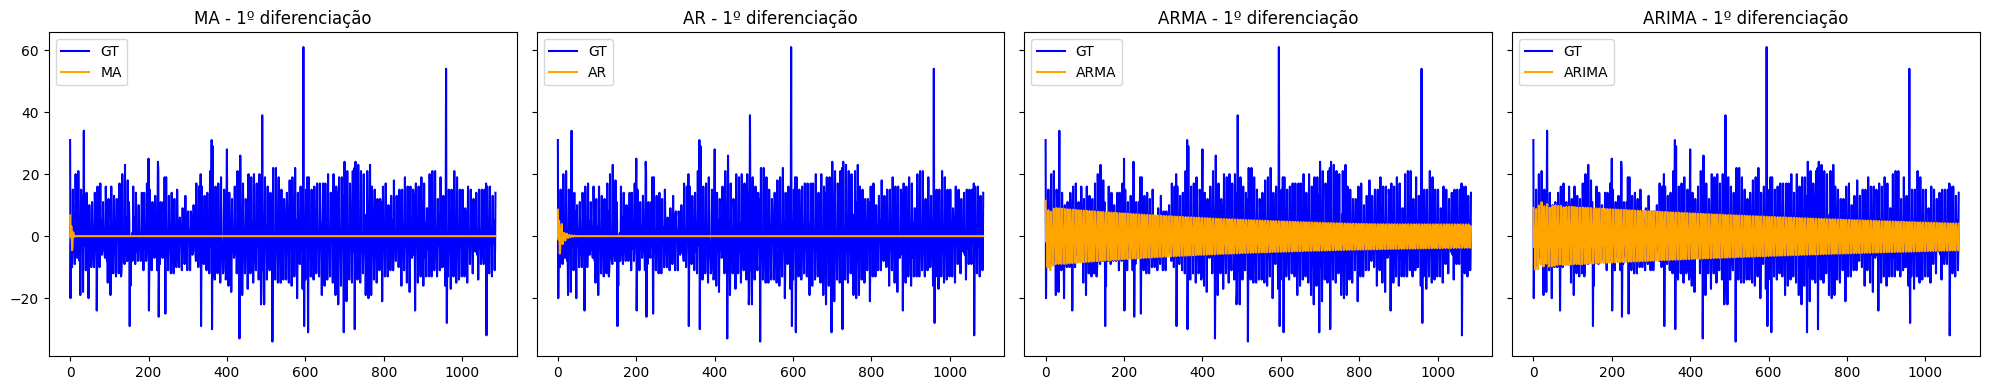

In [64]:
# resultados dos modelos
results = {
    "GT": X_test.squeeze(),
    "MA": ma_results,
    "AR": ar_results,
    "ARMA": arma_results,
    "ARIMA": arima_results
}

df_results = pd.DataFrame(results)

# Lista de modelos (sem o GT)
modelos = ["MA", "AR", "ARMA", "ARIMA"]

# Cria subplots na horizontal
fig, axes = plt.subplots(1, len(modelos), figsize=(20, 4), sharex=True, sharey=True)

for i, modelo in enumerate(modelos):
    axes[i].plot(df_results.index, df_results["GT"], label="GT", color="blue")
    axes[i].plot(df_results.index, df_results[modelo], label=modelo,color='orange')
    axes[i].set_title(f"{modelo} - 1º diferenciação")
    axes[i].legend()

plt.tight_layout()
plt.show()

Observações:

* De forma geral, os dados previstos pelos modelos do AR e MA não apresentaram um resultado bom. Eles não conseguiram se adequar aos valores mais extremos.
* Já os modelos ARMA e ARIMA apresenta uma maior adequação aos dados, ou seja, conseguem prever mais próximo aos valores reais.

2º diferenciação

In [48]:
# ts - time series
ts = df['Google_Trends'].values
ts_diff = differentiate(df['Google_Trends'])
ts_diff2 = differentiate(ts_diff["Diff(m=1)"]).values

# tamanho do teste
test_size = int(len(ts_diff2) * 0.2) # 20% para teste

# df de treino e teste
X_train, X_test = ts_diff2[:-test_size], ts_diff2[-test_size: ]

In [50]:
lag = 12
d = 1

ma_model = ARIMA(X_train, order=[0, 0, lag]) # modelo de média movel - composto pelo ARIMA quando o p e d são zero
ar_model = ARIMA(X_train, order=[lag, 0, 0]) # modelo autoregressivo - composto pelo ARIMA quando o d e q são zero
arma_model = ARIMA(X_train, order=[lag, 0, lag]) # modelo ARMA ( autoregressivo + média móvel ) - composto pelo ARIMA quando a variável d = 0
arima_model = ARIMA(X_train, order=[lag, d, lag]) # modelo ARIMA

In [51]:
ma_results = ma_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [52]:
ar_results = ar_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

In [53]:
arma_results = arma_model.fit().predict(start=len(X_train),
                                        end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [54]:
arima_results = arima_model.fit().predict(start=len(X_train),
                                    end=len(X_train) + len(X_test) - 1)

/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


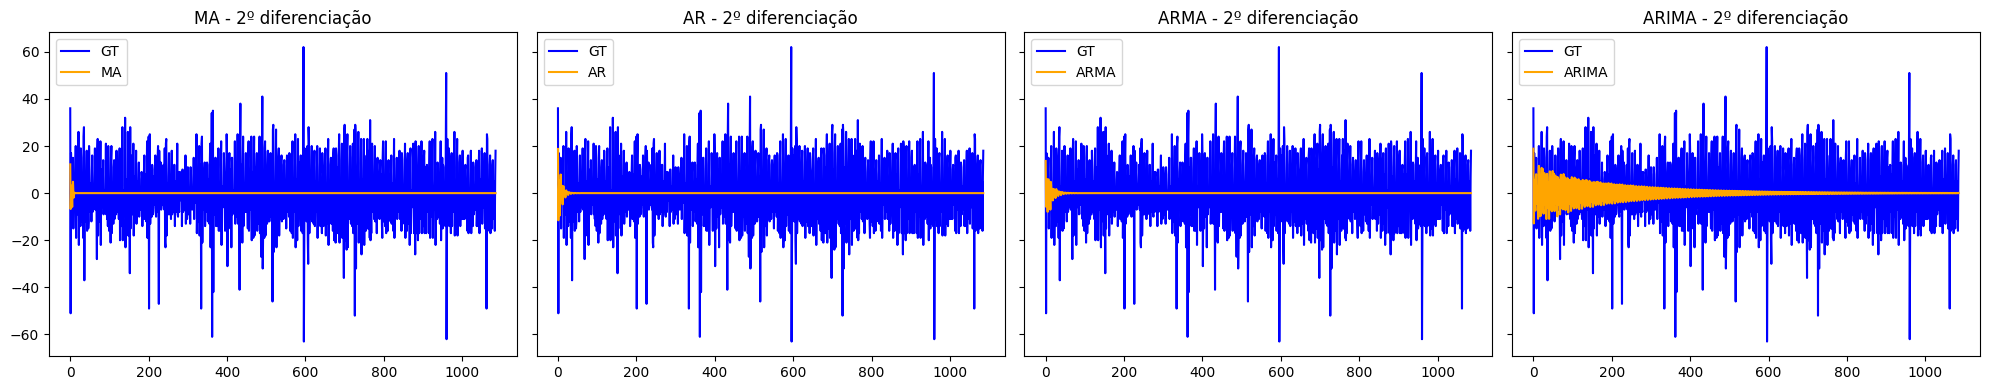

In [56]:
# resultados dos modelos
results = {
    "GT": X_test.squeeze(),
    "MA": ma_results,
    "AR": ar_results,
    "ARMA": arma_results,
    "ARIMA": arima_results
}

df_results = pd.DataFrame(results)

# Lista de modelos (sem o GT)
modelos = ["MA", "AR", "ARMA", "ARIMA"]

# Cria subplots na horizontal
fig, axes = plt.subplots(1, len(modelos), figsize=(20, 4), sharex=True, sharey=True)

for i, modelo in enumerate(modelos):
    axes[i].plot(df_results.index, df_results["GT"], label="GT", color="blue")
    axes[i].plot(df_results.index, df_results[modelo], label=modelo,color='orange')
    axes[i].set_title(f"{modelo} - 2º diferenciação")
    axes[i].legend()

plt.tight_layout()
plt.show()

Observações:

A aplicação da 2º diferenciação afetou os modelos de forma que eles não conseguiram se adequar muito bem quando comparamos com os valores reais, ficando muito centralizado no 0 e não considerando as extremidades.

### Metricas

TODO:
1. Adicionar metricas:
  * Criar métodos para `MAE`, `ARV` e `MAPE`

2. Atualizar `get_metrics` para incluir as novas métricas

3. NOTA: lembrar de atualizar com a inclusão do ARIMA.

In [65]:
def mse(gt: any, pred: any) -> float:
  return np.square(gt - pred).mean()

def rmse(gt: any, pred: any) -> float:
  return np.sqrt(mse(gt, pred))

def mae(gt: any, pred: any) -> float:
  return 1/len(gt) * np.abs(gt - pred).sum()

def arv(gt: any, pred: any) -> float:
  return np.sum((pred - gt) ** 2) / np.sum((gt - np.mean(gt)) ** 2)

def mape(gt: any, pred: any) -> float:
  return 100 / len(gt) * np.abs((gt - pred) / gt).sum()

def get_metrics(gt: any, pred: any) -> dict:
  metrics = {
      "mse": mse(gt, pred),
      "rmse": rmse(gt, pred),
      "mae": mae(gt,pred),
      "arv": arv(gt,pred),
      "mape": mape(gt,pred)
      }

  return metrics

In [66]:
ar_results = get_metrics(results["GT"], results["AR"])
ar_results

{'mse': 98.72097868917174,
 'rmse': 9.9358431292554,
 'mae': 6.852936391535181,
 'arv': 0.9934578526971344,
 'mape': inf}

In [67]:
ma_results = get_metrics(results["GT"], results["MA"])
ma_results

{'mse': 98.94299890098814,
 'rmse': 9.947009545636726,
 'mae': 6.858798607680434,
 'arv': 0.995692106508383,
 'mape': inf}

In [68]:
arma_results = get_metrics(results["GT"], results["ARMA"])
arma_results

{'mse': 61.029096388023014,
 'rmse': 7.812112159206562,
 'mae': 5.34176345659755,
 'arv': 0.6141535047032712,
 'mape': inf}

In [69]:
arima_results = get_metrics(results["GT"], results["ARIMA"])
arima_results

{'mse': 53.708367129900076,
 'rmse': 7.328599261107137,
 'mae': 4.972683709502581,
 'arv': 0.5404828820501996,
 'mape': inf}

Comparações

* Comparando os valores das métricas e os gráficos dos modelos, é possível observar que o ARIMA conseguiu se adequar mais as previsões com os valores reais do que os demais considerando as extremidadess dados como também obteve os menores valores de métricas. Mesmo assim, ainda não foi um resultado ótimo sendo necessário ajustes do setup experimental para diminuir o resíduo entre os valores previstos e reais.

Observação:


* O MAPE sendo infinito indica que amostras com valor zero estavam no dataset.